In [1]:
import numpy as np
from fractions import Fraction
np.set_printoptions(formatter={'all':lambda x: str(Fraction(x).limit_denominator())})

3.(a) Gram-Schmidt:

$$
v_k=w_k-\sum_{i=1}^{k-1}\frac{\langle w_k,v_i\rangle}{\|v_i\|^2}v_i\tag{Thm 6.4}
$$

*see code below*

to get the orthonormal basis, we normalize $v_1$ and $v_2$:

$$
e_1=\frac{v_1}{\|v_1\|}=\begin{pmatrix}\frac{\sqrt{6}}{6}\\\frac{\sqrt{6}}{3}\\\frac{\sqrt{6}}{6}\\0\end{pmatrix},\ \ \ \ \
e_2=\frac{v_2}{\|v_2\|}=\begin{pmatrix}-\frac{\sqrt{30}}{15}\\-\frac{\sqrt{30}}{30}\\\frac{2\sqrt{30}}{15}\\\frac{\sqrt{30}}{10}\end{pmatrix}
$$


In [2]:
def GramSchmidt(w_vector, v_set:list):
    for v_i in v_set:
        w_vector -= ((w_vector@v_i)/(v_i@v_i))*v_i
    return w_vector

w1 = np.array([1, 2, 1, 0], dtype=float)
w2 = np.array([0, 1, 2, 1], dtype=float)
w3 = np.array([1, 0, -3, -2], dtype=float)

v_set = [] # make an empty list for v_set

v1 = w1 # let v1 = w1
print("v1:", v1)
v_set.append(v1) # add v1 into v_set

v2 = GramSchmidt(w2, v_set)
print("v2:", v2)
v_set.append(v2) # add v2 into v_set

v3 = GramSchmidt(w3, v_set)
print("v3:", v3)

v1: [1 2 1 0]
v2: [-2/3 -1/3 4/3 1]
v3: [0 0 0 0]


3.(c) check $A=QR$

In [3]:
Q = np.array([[np.sqrt(6)/6, -np.sqrt(30)/15, 1/2],
              [np.sqrt(6)/3, -np.sqrt(30)/30, -1/2],
              [np.sqrt(6)/6, 2*np.sqrt(30)/15, 1/2],
              [0, np.sqrt(30)/10, -1/2]])
R = np.array([[np.sqrt(6), 2*np.sqrt(6)/3, -np.sqrt(6)/3],
              [0, np.sqrt(30)/3, -2*np.sqrt(30)/3],
              [0, 0, 0]])
print("QR:\n", Q@R)

QR:
 [[1 0 1]
 [2 1 0]
 [1 2 -3]
 [0 1 -2]]


5.(a) check $Ax=RQx=b$

In [4]:
Q = np.array([[1/2, 1/np.sqrt(2), 0],
              [1/2, 0, -1/np.sqrt(2)],
              [1/2, -1/np.sqrt(2), 0], 
              [1/2, 0, 1/np.sqrt(2)]])

R = np.array([[2*np.sqrt(2), 2*np.sqrt(2), 4*np.sqrt(2)],
              [0, 2*np.sqrt(2), -np.sqrt(2)],
              [0, 0, np.sqrt(2)]])

A = Q@R
x = np.array([(7/2)*np.sqrt(2)-3, -1, 2])

print("Ax:", np.dot(A, x))

Ax: [3 5 11 9]


5.(b) compute $P=A(A^TA)^{-1}A^T=QQ^T$

In [5]:
print("A(A^TA)^{-1}A^T:\n", A@np.linalg.inv(A.T@A)@A.T)
print("\nQQ^T:\n", Q@Q.T)

A(A^TA)^{-1}A^T:
 [[3/4 1/4 -1/4 1/4]
 [1/4 3/4 1/4 -1/4]
 [-1/4 1/4 3/4 1/4]
 [1/4 -1/4 1/4 3/4]]

QQ^T:
 [[3/4 1/4 -1/4 1/4]
 [1/4 3/4 1/4 -1/4]
 [-1/4 1/4 3/4 1/4]
 [1/4 -1/4 1/4 3/4]]


4.(c) Least Squares:

Horizontal line approximation:

$$
y = b
= \underbrace{\begin{pmatrix}
1\\1\\\vdots\\1
\end{pmatrix}}_A
\underbrace{b}_x
=Ax
$$

Quadratic line approximation:

$$
y = at^2+b
= \begin{pmatrix}
at_1^2+b\\at_2^2+b\\\vdots\\at_n^2+b
\end{pmatrix}
= \underbrace{\begin{pmatrix}
t_1^2&1\\t_2^2&1\\\vdots&\vdots\\t_n^2&1
\end{pmatrix}}_A
\underbrace{\begin{pmatrix}
a\\b
\end{pmatrix}}_x
=Ax
$$

closed-form solution:

$$
x=(A^TA)^{-1}A^Ty\tag{Thm 6.12}
$$

*see code below*

Horizontal line approximation and Quadratic line approximation has the same result,
i.e., adding a quadratic term does not improve in this model.


Least Squares approximation with horinzontal function
coef: [4]
error: 34.0

Least Squares approximation with quadratic function
coef: [0 4]
error: 34.0


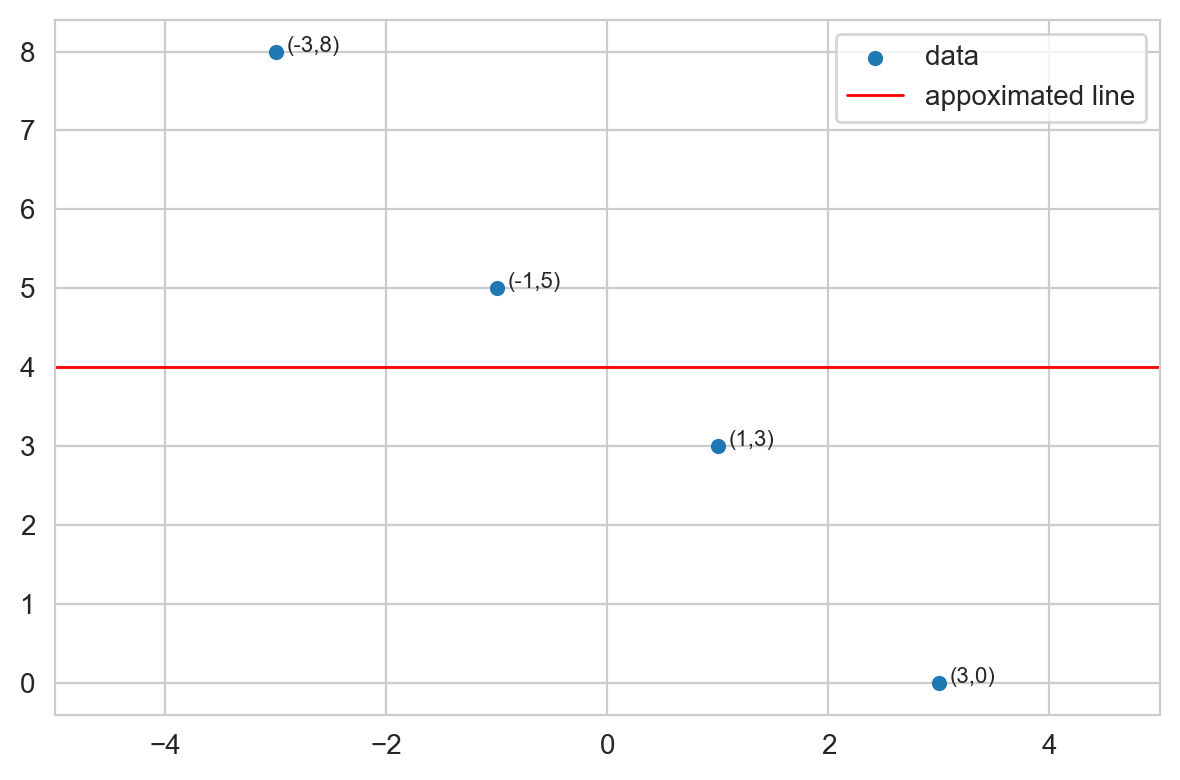

In [6]:
class least_squares:
    def __init__ (self, data:list, label:list, approximate="linear", verbose=False):

        self.n = len(data)
        self.t = np.array(data)
        self.y = np.array(label)

        if approximate == "horinzontal":
            self.A = self.linear()
        if approximate == "quadratic":
            self.A = self.quadratic()
        
        self.x = self.solve()
        self.E = self.error()

        if verbose:
            print("\nLeast Squares approximation with " + approximate + " function")
            print("coef:", self.x)
            print("error:", np.round(self.E, 5))
    
    def linear(self):
        A = np.ones((self.n, 1))
        return A

    def quadratic(self):
        A = np.ones((self.n, 2)) # make a (nx2) matrix with elements all 1
        A[:,0] = self.t**2 # change the first column to t^2
        return A

    def solve(self):
        ''' Theorem 6.12 '''
        x = np.linalg.inv(self.A.T@self.A)@self.A.T@self.y
        return x

    def error(self):
        res = self.y - self.A@self.x # residual
        return np.dot(res, res) # error

t = [-3, -1, 1, 3]
y = [8, 5, 3, 0]

solver = least_squares(data=t, label=y, approximate="horinzontal", verbose=True)
solver = least_squares(data=t, label=y, approximate="quadratic", verbose=True)


import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, ax = plt.subplots(1, 1 ,figsize=(6, 4), dpi=200)

ax.scatter(t, y, s=20, label="data")
ax.plot([-5, 5], [4, 4], "-", c="red", linewidth=1, label="appoximated line")

for i in range(4):
    ax.text(t[i]+0.1, y[i], "("+str(t[i])+","+str(y[i])+")", fontsize=8)

ax.set_xlim(-5, 5)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()